In [1]:
import numpy as np
import pandas as pd
import math
import time
import random
import matplotlib.pyplot as plt

from collections import namedtuple,deque

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch
import BSS_ENV_shortduration as BE

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
#单一行为以及可拓展的策略
class options:
    def __init__(self,num):
        self.charger_num = num
        self.ev_num = num
        self.bssbatterynum = 2 * num
        self.maxpve = 0
        self.transit_step = 2
        self.ev_average_worksoc = 0.1

        self.inp_dim = 4
        self.memory_count = 1000
        self.GAMMA = 0.99
        self.beta = 0.2
        self.MEMORY_NUM = 3
        self.game_step = 400
        
        self.NUM_EPISODES = 8000

        self.update_gamecount = 4#每进行多少轮游戏更新网络

        self.learning_ratio = 0.001
        self.if_clamp = True
        self.modelpath = r'D:\sjtu\EV_DRL\BSS_OPERATION_Emergence\data\savemodel\policymodel'
        self.dirpath=r'D:\sjtu\EV_DRL\BSS_OPERATION\data'
        self.gru_state = r'D:\sjtu\EV_DRL\BSS_OPERATION\data\savemodel\gru.pth'
        #self.price_data = r'D:\sjtu\xdd\paper\data\price\time_series_60min_singleindex.csv'
        self.price_data = r'D:\sjtu\EV_DRL\BSS_OPERATION_Emergence\data\pricedata\time_series_60min_singleindex.csv'
        #模型的初始化格式
        self.pit = {'avg':0,'ban':1,'all':2}#等概率考虑pv，不使用pv，最大化使用pv
        

OPTIONS = options(10)

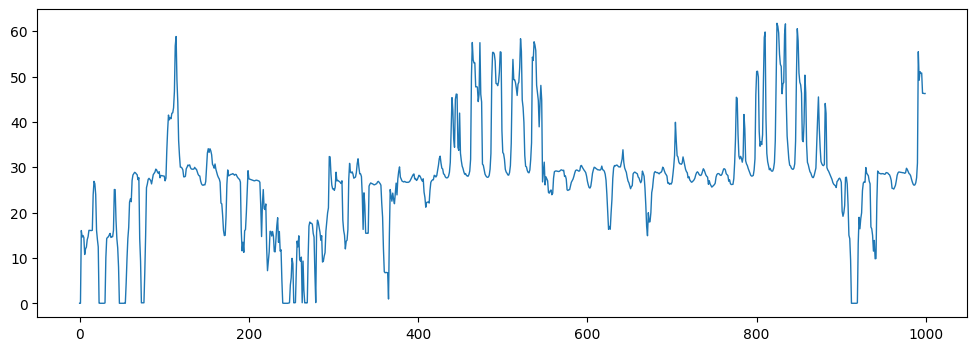

In [3]:
price_data_path = OPTIONS.price_data
pd_frame = pd.read_csv(price_data_path)

DK_1_price = pd_frame['DK_1_price_day_ahead']
DK_1_price.fillna(0,inplace=True)

DK_1_price_nparray =np.array([max(0,i) for i in DK_1_price.tolist()])

fig, ax = plt.subplots(figsize = (12,4))
ax.plot(np.arange(1000), DK_1_price_nparray[0:1000], linewidth=1)
plt.show()

In [4]:
GM = BE.GameManager(OPTIONS,ps_eprice_ds=DK_1_price_nparray)
def StateTensor(gm:BE.GameManager):
    bt1_num,bt2_num,b_num,energy_cost,carbon,bssevqueue_length,wasted_reserve,ctime,is_done = gm.EnvState()
    ctime = ctime/10 #0-96的数值太大，这里减少一下数值大小
    statetensor = torch.tensor([bt1_num,bt2_num,bssevqueue_length,ctime],dtype= torch.float32).to(device)
    costtensor = torch.tensor([energy_cost,bssevqueue_length,wasted_reserve],dtype= torch.float32).to(device)
    return statetensor.unsqueeze(0),costtensor.unsqueeze(0) #1*4 ,1*3

cfactor_t1 = 0.05
qfactor_t1 = 1
wfactor_t1 = 0.5
def rewardtype1(cost_T,opts:options):#正常运营状态下的奖励信息，车辆排队数量+超出的预约数+充电费用

    charging_cost = cfactor_t1* cost_T[:,0]/120#120为电池容量，这里电费最好按照SOC的比例计算，因此除掉了电池容量

    emergenceqfactor = 1 if opts.ev_num/cost_T[:,1]>1.5 else 3
    evqueuetimein_bss = qfactor_t1*(cost_T[:,1])*emergenceqfactor

    wast_request = wfactor_t1*cost_T[:,2]
       
    #print(evqueuetimein_bss, wast_request,charging_cost)
    bss_reward = -(evqueuetimein_bss+ wast_request+charging_cost)/opts.ev_num
    #print(torch.ones(1),bss_reward)
    bss_reward = bss_reward.unsqueeze(0) #奖励值输入形状为1*
    return bss_reward


def rewardtype1_detail(cost_T,opts:options):#正常运营状态下的奖励信息，车辆排队数量+超出的预约数+充电费用

    charging_cost = cfactor_t1* cost_T[:,0]/120#120为电池容量，这里电费最好按照SOC的比例计算，因此除掉了电池容量

    emergenceqfactor = 1 if opts.ev_num/cost_T[:,1]>1.5 else 3
    evqueuetimein_bss = qfactor_t1*(cost_T[:,1])*emergenceqfactor

    wast_request = wfactor_t1*cost_T[:,2]
       
    #print(evqueuetimein_bss, wast_request,charging_cost)
    bss_reward = -(evqueuetimein_bss+ wast_request+charging_cost)/opts.ev_num
    #print(torch.ones(1),bss_reward)
    bss_reward = bss_reward.unsqueeze(0) #奖励值输入形状为1*
    return bss_reward,-charging_cost,-evqueuetimein_bss,-wast_request

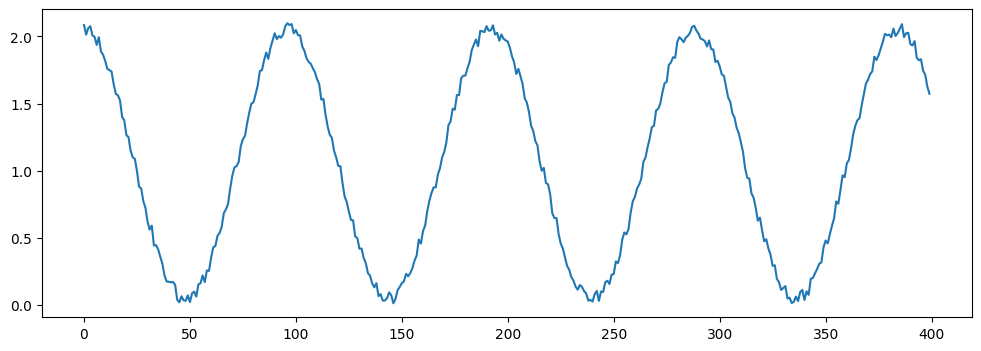

In [5]:
workingtimes= range(400)
timereturn = 48
worktimefactor =   [1 * math.cos(i*math.pi/timereturn) + 1  + random.random()*0.1 for i in workingtimes] 
fig = plt.figure(figsize = (12,4))
plt.plot(workingtimes,worktimefactor)
plt.show()

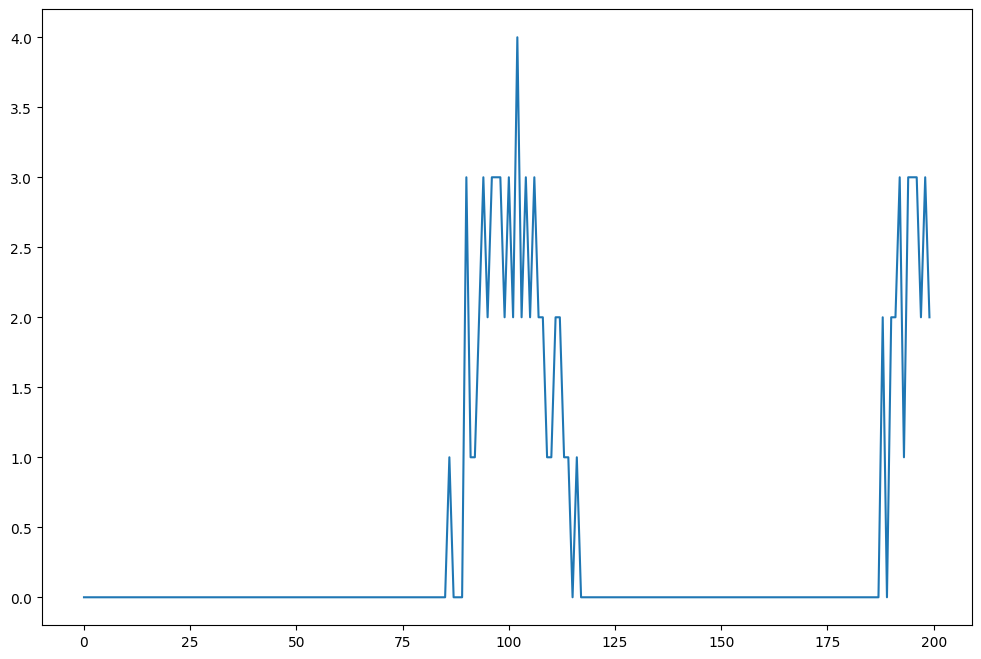

In [6]:
evqueuelengths = []
for i in range(200):#OPTIONS.game_step):
    reserve = int(OPTIONS.charger_num/2)
    chargeplan = 1
    GM.Update(reserve,chargeplan) 
    cstate,ccost = StateTensor(GM)
    evqueuelengths.append(ccost[:,1].cpu().item())
    #print(i,cstate,ccost)
    r = rewardtype1(ccost,OPTIONS)
    #print(r)
    #GM.Message()

fig = plt.figure(figsize = (12,8))
plt.plot(range(200),evqueuelengths)
plt.show()

In [7]:
class PPONetwork(torch.nn.Module):
    def __init__(self,inpdim,reserve_dim=5,init_cpratio_id = 1):
        super(PPONetwork,self).__init__()
        self.inputlayer = torch.nn.Linear(inpdim,64).to(device)
        self.linear1 = torch.nn.Linear(64,128).to(device)

        #self.norm = torch.nn.BatchNorm1d(4).to(device)
        #self.relu = torch.nn.LeakyReLU().to(device)

        self.linear2 = torch.nn.Linear(128,64).to(device)

        self.out1 = torch.nn.Linear(64,reserve_dim).to(device)
        #self.out2 = torch.nn.Linear(64,chargeplan_dim).to(device)
        self.out3 = torch.nn.Linear(64,1).to(device)
        self.softmax = torch.nn.Softmax(dim=-1)
        
        
    def forward(self,inp):
        x = inp.to(device)
        inp1 = self.inputlayer(x)
        tanh1 = torch.nn.Tanh()(inp1)
        line1 = self.linear1(tanh1)
        line2 = self.linear2(line1)#(reshape_128)
        tanh2 = torch.nn.Tanh()(line2)
        #print(tanh2)
        out_1 = self.out1(tanh2)
        
        out_3 = self.out3(tanh2)
        res1 = self.softmax(out_1)

        #print(out_3)
        res3 = out_3
        return res1,res3 #bs*reservedim+1,bs*2,bs*1

In [8]:
BSSTransition = namedtuple('BSSTransition',('state_pool','value_pool','policy_ratio_pool','clipres_pool','log_prob_pool','reward_pool','done_pool'))#收集连续动作
class BSSMemory(object):#策略梯度采样，每次保存一次策略的数据，采样一次策略的数据、
    def __init__(self,capacity):
        self.memory = deque([],maxlen = capacity)
    def push(self,*args):
        self.memory.append(BSSTransition(*args))
    def sample(self):
        batch = list(self.memory)
        return zip(*batch)
    def __len__(self):
        return len(self.memory)
    def clear(self):
        self.memory.clear()


class BSS_DRL(object):#er_dim=5*5+1默认单位电量20，5个100kwh充电桩对应的维度选择为25+1
    def __init__(self,opt):#ifstep 通过冻结网络的部分层操作实现分段训练):
        self.options =  opt
        self.lr = opt.learning_ratio
        
        self.bss_agent = PPONetwork(opt.inp_dim,reserve_dim=opt.charger_num +1,init_cpratio_id= 0).to(device)
        
        self.bss_agent_target = PPONetwork(opt.inp_dim,reserve_dim=opt.charger_num +1,init_cpratio_id=0).to(device)
        self.bss_agent_target.load_state_dict(self.bss_agent.state_dict())  
        self.bss_agent_target.eval()

        self.bss_agent_optimizer = torch.optim.Adam(self.bss_agent.parameters(),lr = self.lr)
        #self.bss_a2c_target_optimizer = torch.optim.Adam(self.evrp_critic.parameters(),lr = self.lr)
        self.if_clamp = opt.if_clamp
        self.bssmemory_num = opt.MEMORY_NUM
        self.bssmemorys = [] 
        for i in range(4):
            self.bssmemorys.append(BSSMemory(2500))
        
    #根据当前状态 选择车辆充电行为， 首先根据车辆策略模型给出期望充电行为， 再依据充电商策略模型给出确定动作   
    def select_action(self,bssstate,if_train=False):#state_s的格式为bs*ev_num*(state_n)
        prob1,state_value = self.bss_agent(bssstate)
        prob1_target,state_value_target = self.bss_agent_target(bssstate)
        
        reserve_dist = torch.distributions.categorical.Categorical(prob1)
   
        reserve_dist_target = torch.distributions.categorical.Categorical(prob1_target)
        
        
        reserve_act = reserve_dist.sample()

        reserve_act_target = reserve_dist_target.sample()
        
        
        if if_train:
            return reserve_act_target,reserve_dist_target,reserve_dist,state_value_target
                
        return reserve_act,prob1
    
    
    def cliprange(self,prob,prob_target,segma=0.2):
        policy_ratio = prob/prob_target
        max_clip = 1+segma
        min_clip = 1-segma
        clipres = torch.clamp(policy_ratio,min = min_clip,max = max_clip)
        return clipres
    
    def compute_returns(self,next_value, rewards, masks, gamma=0.99):
        value = next_value.detach()#return 不计入梯度计算，这里使用detach() 1*1
        rewards = (rewards - rewards.mean())/rewards.std()
       
        returns = torch.zeros_like(rewards)    #使用numpy操作可能更快？但是需要注意tensor和numpy数据的转换
        for act_i in reversed(range(len(rewards))):
            #print(rewards[act_i],gamma , value , masks[act_i])
            value = rewards[act_i] + gamma * value * (1-masks[act_i])
            returns[act_i] = value
        return returns #pool_size*1*1

    def update_bss(self,nstate_s_list,entropys):
        #print(0.001*entropy)
        mmnum = self.bssmemory_num
        losses = []
        for i in range(self.bssmemory_num):
            state_pool,value_pool,policy_ratio_pool,clipres_pool,log_prob_pool,reward_pool,done_pool= self.bssmemorys[i].sample()

            state_poolstack =torch.stack(state_pool).to(device)
            old_value_poolstack = torch.stack(value_pool).to(device)#pool_length*bs*valuedim
            policy_ratio_poolstack = torch.stack(policy_ratio_pool).to(device) #pool_length*bs*valuedim
            clipres_poolstack = torch.stack(clipres_pool).to(device) #pool_length*bs*valuedim
            #print(value_poolstack)
            log_prob_poolstack = torch.stack(log_prob_pool).to(device) #pool_length*bs*valuedim
            #print(log_prob_poolstack)
            reward_poolstack = torch.stack(reward_pool).to(device)#pool_length*bs*valuedim
            #print(reward_poolstack)
            done_poolstack = torch.stack(done_pool).to(device)#pool_length*bs*valuedim
            #print(done_poolstack)
       
            #1 1 1
            _,next_value = self.bss_agent_target(nstate_s_list[i])#bs*1
        
            #记录累加奖励（该采样与DQN不同，采样中每次仅记录一个策略动作序列）
            returns = self.compute_returns(next_value.squeeze(0),reward_poolstack,done_poolstack,gamma = self.options.GAMMA)
            advantages = returns - old_value_poolstack

            _,current_value = self.bss_agent(state_poolstack)
            #print(current_value.shape,returns.shape)
            current_advantage = returns - current_value
            
            #print(advantages.shape)
            # print('clip'+str(clipres_poolstack))
            # print('policy' +str( policy_ratio_poolstack))
            clip_advantages = advantages * clipres_poolstack
            policy_ratio_advantages = advantages * policy_ratio_poolstack
            # print(clip_advantages)
            # print(policy_ratio_advantages)
            stack_advantages = torch.cat((clip_advantages,policy_ratio_advantages),dim=-1)
            ppo_advantages = stack_advantages.min(dim=-1)[0].unsqueeze(-1)
            
            #print( ppo_advantages)
            #print(advantages)
            #print(log_prob_poolstack)
            #print(advantages)
            
            actor_loss = -ppo_advantages.mean() # (-log_prob_poolstack * advantages).mean()
            critic_loss = 0.5 * current_advantage.pow(2).mean()
            # print('bss动作损失：{}'.format(actor_loss))
            # print('bss策略损失：{}'.format(critic_loss))
            total_loss = 10* actor_loss + critic_loss - 0.0001*entropys[i]
            losses.append(total_loss)
        
        mmloss = losses[0]
        for i in range( mmnum-1):
            mmloss = mmloss + losses[i+1]
        mmloss = mmloss/mmnum
        #print('动作熵值：{}'.format(log_prob_poolstack))            
        self.bss_agent_optimizer.zero_grad()      
        mmloss.backward()
        if self.if_clamp:
            for param in self.bss_agent.parameters():           
                #print(param.grad)
                if param.grad is not None:
                    param.grad.data.clamp(-20,20)
        #for param in self.evrp_critic.parameters():           
           # print(param.grad)
        self.bss_agent_optimizer.step()    


    def update_bss_for_loss(self,nstate_s_list,entropys):
        #print(0.001*entropy)
        mmnum = self.bssmemory_num
        losses = []
        for i in range(self.bssmemory_num):
            state_pool,value_pool,policy_ratio_pool,clipres_pool,log_prob_pool,reward_pool,done_pool= self.bssmemorys[i].sample()

            state_poolstack =torch.stack(state_pool).to(device)
            old_value_poolstack = torch.stack(value_pool).to(device)#pool_length*bs*valuedim
            policy_ratio_poolstack = torch.stack(policy_ratio_pool).to(device) #pool_length*bs*valuedim
            clipres_poolstack = torch.stack(clipres_pool).to(device) #pool_length*bs*valuedim
            #print(value_poolstack)
            log_prob_poolstack = torch.stack(log_prob_pool).to(device) #pool_length*bs*valuedim
            #print(log_prob_poolstack)
            reward_poolstack = torch.stack(reward_pool).to(device)#pool_length*bs*valuedim
            #print(reward_poolstack)
            done_poolstack = torch.stack(done_pool).to(device)#pool_length*bs*valuedim
            #print(done_poolstack)
       
            #1 1 1
            _,next_value = self.bss_agent_target(nstate_s_list[i])#bs*1
        
            #记录累加奖励（该采样与DQN不同，采样中每次仅记录一个策略动作序列）
            returns = self.compute_returns(next_value.squeeze(0),reward_poolstack,done_poolstack,gamma = self.options.GAMMA)
            advantages = returns - old_value_poolstack

            _,current_value = self.bss_agent(state_poolstack)
            #print(current_value.shape,returns.shape)
            current_advantage = returns - current_value
            
            #print(advantages.shape)
            # print('clip'+str(clipres_poolstack))
            # print('policy' +str( policy_ratio_poolstack))
            clip_advantages = advantages * clipres_poolstack
            policy_ratio_advantages = advantages * policy_ratio_poolstack
            # print(clip_advantages)
            # print(policy_ratio_advantages)
            stack_advantages = torch.cat((clip_advantages,policy_ratio_advantages),dim=-1)
            ppo_advantages = stack_advantages.min(dim=-1)[0].unsqueeze(-1)
            
            #print( ppo_advantages)
            #print(advantages)
            #print(log_prob_poolstack)
            #print(advantages)
            
            actor_loss = -ppo_advantages.mean() # (-log_prob_poolstack * advantages).mean()
            critic_loss = 0.5 * current_advantage.pow(2).mean()
            # print('bss动作损失：{}'.format(actor_loss))
            # print('bss策略损失：{}'.format(critic_loss))
            total_loss = 10* actor_loss + critic_loss - 0.0001*entropys[i]
            losses.append(total_loss)
        
        mmloss = losses[0]
        for i in range( mmnum-1):
            mmloss = mmloss + losses[i+1]
        mmloss = mmloss/mmnum
        return mmloss
            #print('动作熵值：{}'.format(log_prob_poolstack))            
        # self.bss_agent_optimizer.zero_grad()      
        # mmloss.backward()
        # if self.if_clamp:
        #     for param in self.bss_agent.parameters():           
        #         #print(param.grad)
        #         if param.grad is not None:
        #             param.grad.data.clamp(-20,20)
        # #for param in self.evrp_critic.parameters():           
        #    # print(param.grad)
        # self.bss_agent_optimizer.step()    
        
        
    def savemodel(self,dicpath,addname):
        torch.save(self.bss_agent.state_dict(),os.path.join(dicpath,addname+'.pth'))



In [9]:
reward = rewardtype1

bss_ep_valrewards = []
bss_ep_valrewards_avgemgf = []

meta_drl =  BSS_DRL(OPTIONS)
sub_drl025 =  BSS_DRL(OPTIONS)
sub_drl050 =  BSS_DRL(OPTIONS)
sub_drl075 =  BSS_DRL(OPTIONS)
sub_drl100 =  BSS_DRL(OPTIONS)
sub_drl125 =  BSS_DRL(OPTIONS)
sub_drl150 =  BSS_DRL(OPTIONS)
sub_drls = [sub_drl025,sub_drl050,sub_drl075,sub_drl100,sub_drl125,sub_drl150]
emergencefactors = [0.25,0.5,0.75,1,1.25,1.5]
subtaskid = [0,1,2,3,4,5]
sample_subtasknum = 2

In [10]:
#bss_drl.bss_agent.load_state_dict(torch.load(os.path.join(OPTIONS.modelpath,'PPO_emgfactor1_SCALE10.pth')))

In [ ]:
for ep in range(4000):# (OPTIONS.NUM_EPISODES+1000): # 
    start = time.time()#记录每个episode训练时间       
       
    samplesampletask = random.sample(subtaskid,k = sample_subtasknum)
    samplesampletask#
    subtask1_model = sub_drls[samplesampletask[0]] 
    subtask1_emgfactor = emergencefactors[samplesampletask[0]]
    subtask2_model = sub_drls[samplesampletask[1]]
    subtask2_emgfactor = emergencefactors[samplesampletask[1]]

    subtask1_model.bss_agent.load_state_dict(meta_drl.bss_agent.state_dict())
    subtask1_model.bss_agent_target.load_state_dict(meta_drl.bss_agent_target.state_dict())

    subtask2_model.bss_agent.load_state_dict(meta_drl.bss_agent.state_dict())
    subtask2_model.bss_agent_target.load_state_dict(meta_drl.bss_agent_target.state_dict())

    subtask_infs = [[subtask1_model,subtask1_emgfactor],[subtask2_model,subtask2_emgfactor]]

    eposide_loss = []

    for i in range(sample_subtasknum):
        current_subtaskmode = subtask_infs[i][0]
        current_task_emgfactor = subtask_infs[i][1]
        bss_ep_entropys = [] 
        bss_last_state_s=[]

    #submodel 先更新一次
        for k in range(OPTIONS.MEMORY_NUM):#每次采样四局仿真#为4个记忆槽分别采样4次行为       
            GM.Initial(reinitial= True)
            cstate,ccoststate = StateTensor(GM)
            ep_bss_entropy = 0
            
            for j in range(OPTIONS.game_step):            
                
                #1*1,1*1*15 ,1*1*1 
                reserve_act_target,reserve_dist_target,reserve_dist,state_value_target = current_subtaskmode.select_action(cstate,True)
                
                state_value = state_value_target #1*1
                #由于模型中考虑了batch因素，所以state_value结构为bs*ev_num,单个取值时bs为1，由于采样后，使用了stack堆积，需要把把第一维度去掉
                    
                #计算采样动作的熵值1*1

                log_prob = reserve_dist.log_prob(reserve_act_target) #+ pvratio_dist.log_prob(pv_act_target) #,1
                log_prob = log_prob.unsqueeze(0) #1*1
                bss_entropy = reserve_dist.entropy().mean()# + pvratio_dist.entropy().mean()#策略动作概率熵值

                rsr_act_prob_target = reserve_dist_target.probs[:,reserve_act_target]
                
                # print(energy_dist_target.probs[:,energy_act_target] )
                # print(energy_dist.probs[:,energy_act_target])
                prob_target = (rsr_act_prob_target).detach() # rsr_act_prob_target.detach()# 
                
                rsr_act_prob = reserve_dist.probs[:,reserve_act_target]
                
                prob = rsr_act_prob
                
                policy_ratio = prob/prob_target
                
                clipres = current_subtaskmode.cliprange(prob,prob_target)
                
                #根据动作更新环境
                charge_request = reserve_act_target.cpu().item()
                
                #print(energy_request,pv_ratio)
                
                GM.Update(charge_request,0,current_task_emgfactor)
                
                #记录下一状态和动作奖励与是否完成目标
                nstate,ncoststate = StateTensor(GM)
                
                #shape 1
                r = reward(ncoststate,OPTIONS) #1,1
                r = r.detach()

                isdone = torch.ones_like(r) * 0
                
                #记录了结束状态
                
                
                #依次记录本次策略动作数据，并放入对应局数的记忆中
                current_subtaskmode.bssmemorys[k].push(cstate,state_value,policy_ratio,clipres,log_prob,r,isdone)
                        
            
                #将下一阶段状态标记为当前状态，并记录累积策略熵
                cstate = nstate 
                ccoststate = ncoststate
                
                ep_bss_entropy += bss_entropy 
               
        
            
            #达到目标或进入摆烂状态都强行结束环境，避免模型收敛到摆烂状态
                # if isdone :#当完成营收目标时，环境工作完毕，结束环境   
                #     break; 
                    
            bss_last_state_s.append(cstate)
            bss_ep_entropys.append(ep_bss_entropy)  
        
        current_subtaskmode.update_bss(bss_last_state_s,bss_ep_entropys)#策略更新时，使用动作序列更新
        
        for mm in current_subtaskmode.bssmemorys:
            mm.clear()#更新后需要清楚本次的动作序列

        bss_ep_entropys = [] 
        bss_last_state_s=[]
    #submodel 更新后再次记录，但不继续更新，仅记录loss
        for k in range(OPTIONS.MEMORY_NUM):#每次采样四局仿真#为4个记忆槽分别采样4次行为       
            GM.Initial(reinitial= True)
            cstate,ccoststate = StateTensor(GM)
            ep_bss_entropy = 0
            
            for j in range(OPTIONS.game_step):            
                
                #1*1,1*1*15 ,1*1*1 
                reserve_act_target,reserve_dist_target,reserve_dist,state_value_target = current_subtaskmode.select_action(cstate,True)
                
                state_value = state_value_target #1*1
                #由于模型中考虑了batch因素，所以state_value结构为bs*ev_num,单个取值时bs为1，由于采样后，使用了stack堆积，需要把把第一维度去掉
                    
                #计算采样动作的熵值1*1

                log_prob = reserve_dist.log_prob(reserve_act_target) #+ pvratio_dist.log_prob(pv_act_target) #,1
                log_prob = log_prob.unsqueeze(0) #1*1
                bss_entropy = reserve_dist.entropy().mean()# + pvratio_dist.entropy().mean()#策略动作概率熵值

                rsr_act_prob_target = reserve_dist_target.probs[:,reserve_act_target]
                
                # print(energy_dist_target.probs[:,energy_act_target] )
                # print(energy_dist.probs[:,energy_act_target])
                prob_target = (rsr_act_prob_target).detach() # rsr_act_prob_target.detach()# 
                
                rsr_act_prob = reserve_dist.probs[:,reserve_act_target]
                
                prob = rsr_act_prob
                
                policy_ratio = prob/prob_target
                
                clipres = current_subtaskmode.cliprange(prob,prob_target)
                
                #根据动作更新环境
                charge_request = reserve_act_target.cpu().item()
                
                #print(energy_request,pv_ratio)
                
                GM.Update(charge_request,0,current_task_emgfactor)
                
                #记录下一状态和动作奖励与是否完成目标
                nstate,ncoststate = StateTensor(GM)
                
                #shape 1
                r = reward(ncoststate,OPTIONS) #1,1
                r = r.detach()

                isdone = torch.ones_like(r) * 0
                
                #记录了结束状态
                
                
                #依次记录本次策略动作数据，并放入对应局数的记忆中
                current_subtaskmode.bssmemorys[k].push(cstate,state_value,policy_ratio,clipres,log_prob,r,isdone)
                        
            
                #将下一阶段状态标记为当前状态，并记录累积策略熵
                cstate = nstate 
                ccoststate = ncoststate
                
                ep_bss_entropy += bss_entropy 
               
        
            
            #达到目标或进入摆烂状态都强行结束环境，避免模型收敛到摆烂状态
                # if isdone :#当完成营收目标时，环境工作完毕，结束环境   
                #     break; 
                    
            bss_last_state_s.append(cstate)
            bss_ep_entropys.append(ep_bss_entropy)  
        
        currentloss = current_subtaskmode.update_bss_for_loss(bss_last_state_s,bss_ep_entropys)#策略更新时，使用动作序列更新
        eposide_loss.append(currentloss)

        for mm in current_subtaskmode.bssmemorys:
            mm.clear()#更新后需要清楚本次的动作序列
    
    meta_drl.bss_agent_optimizer.zero_grad()
    subtask1_model.bss_agent_optimizer.zero_grad()
    subtask2_model.bss_agent_optimizer.zero_grad()

    loss1 = eposide_loss[0].backward(retain_graph = True)
    loss2 = eposide_loss[1].backward()
    # for param in subtask1_model.bss_agent.parameters():           
    #     print(param.grad)
    # print('------------------------------------------------------------------')    
    # for param in subtask2_model.bss_agent.parameters():           
    #     print(param.grad)
    with torch.no_grad():
        for p1,p2,p3 in zip(meta_drl.bss_agent.parameters(),subtask1_model.bss_agent.parameters(),subtask2_model.bss_agent.parameters()):
            if p2.grad is not None and p3.grad is not None:
                p1.grad = (p2.grad+p3.grad)/2
    # print('------------------------------------------------------------------')            
    # for param in meta_drl.bss_agent.parameters():           
    #     print(param.grad)
    meta_drl.bss_agent_optimizer.step()

    randomemgfactor = random.sample(emergencefactors,k=1)[0]
    bss_ep_valreward = 0
    #这里对meta_model 进行一次测试
    GM.Initial(reinitial= True)
    cstate,ccoststate = StateTensor(GM)
    for j in range(OPTIONS.game_step):            
                
        #1*1,1*1*15 ,1*1*1 
        reserve_act,actprob = meta_drl.select_action(cstate)
          
        #根据动作更新环境
        charge_request = reserve_act.cpu().item()
        
        #print(energy_request,pv_ratio)
        
        GM.Update(charge_request,0,randomemgfactor)
        
        #记录下一状态和动作奖励与是否完成目标
        nstate,ncoststate = StateTensor(GM)
        
        #shape 1
        r = reward(ncoststate,OPTIONS) #1,1
        r = r.detach()

        bss_ep_valreward += float(r)     
   
    bss_ep_valrewards.append(bss_ep_valreward)    
    bss_ep_valrewards_avgemgf.append(bss_ep_valreward/randomemgfactor)            
    if ep%2==0:
        print('更新old网络')
        meta_drl.bss_agent_target.load_state_dict(meta_drl.bss_agent.state_dict())
        
        
    print ('第{}轮训练用时{:.3f}秒，平均累积奖励为{:.3f}'.format(
        ep + 1, time.time()-start,bss_ep_valreward/randomemgfactor))



    #valicationmessage(24)
#('current_state','goal_action','ev_prob','reward','next_state'))  

更新old网络
第1轮训练用时11.503秒，平均累积奖励为-281.581
第2轮训练用时11.389秒，平均累积奖励为-281.716
更新old网络
第3轮训练用时11.959秒，平均累积奖励为-503.462
第4轮训练用时11.602秒，平均累积奖励为-308.113
更新old网络
第5轮训练用时11.895秒，平均累积奖励为-502.409
第6轮训练用时11.651秒，平均累积奖励为-307.488
更新old网络
第7轮训练用时11.621秒，平均累积奖励为-267.616
第8轮训练用时11.692秒，平均累积奖励为-292.542
更新old网络
第9轮训练用时11.419秒，平均累积奖励为-282.952
第10轮训练用时11.502秒，平均累积奖励为-257.816
更新old网络
第11轮训练用时11.412秒，平均累积奖励为-308.947
第12轮训练用时11.466秒，平均累积奖励为-297.190
更新old网络
第13轮训练用时11.328秒，平均累积奖励为-276.491
第14轮训练用时11.152秒，平均累积奖励为-273.423
更新old网络
第15轮训练用时11.329秒，平均累积奖励为-278.588
第16轮训练用时11.295秒，平均累积奖励为-273.190
更新old网络
第17轮训练用时11.308秒，平均累积奖励为-284.513
第18轮训练用时11.350秒，平均累积奖励为-264.352
更新old网络
第19轮训练用时11.333秒，平均累积奖励为-267.963
第20轮训练用时11.614秒，平均累积奖励为-270.291
更新old网络
第21轮训练用时11.406秒，平均累积奖励为-254.983
第22轮训练用时11.226秒，平均累积奖励为-293.275
更新old网络
第23轮训练用时11.232秒，平均累积奖励为-267.597
第24轮训练用时11.245秒，平均累积奖励为-276.341
更新old网络
第25轮训练用时11.180秒，平均累积奖励为-344.896
第26轮训练用时11.139秒，平均累积奖励为-300.894
更新old网络
第27轮训练用时11.257秒，平均累积奖励为-236.396
第28轮训练用时11.527秒，平均累积奖励为-295.728
更

In [14]:
torch.save(meta_drl.bss_agent.state_dict(),f=r'D:\sjtu\EV_DRL\BSS_OPERATION_Emergence\data\savemodel\policymodel\PPO_emgfactor050v1_SCALE10_singleact_metamodel.pth')

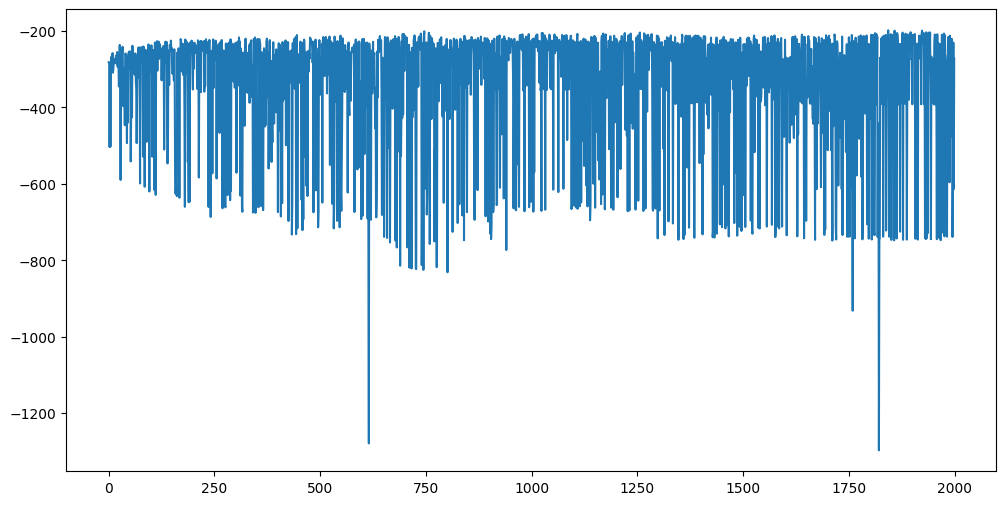

In [12]:
fig = plt.figure(figsize = (12,6))
x = range(len(bss_ep_valrewards_avgemgf))
ep_rewards_arr =bss_ep_valrewards_avgemgf 
plt.plot(x,ep_rewards_arr)
plt.show()

In [13]:
ep_rewards_pd = pd.DataFrame(ep_rewards_arr)
pdpath = r'D:\sjtu\EV_DRL\BSS_OPERATION_Emergence\data\实验数据\训练数据\PPO_emgfactor050v1_SCALE10_singleact_trainreturn.csv'
ep_rewards_pd.to_csv(pdpath,header=['return'],index=None)

In [ ]:
def test(step,gamemanager:BE.GameManager,rewardF,opt, model=None,showmessage = True,savepic = False):
    gamemanager.Initial( reinitial= True)
    print('仿真开始')
    #gamemanager.Message()
    request_reserve_list = []
    request_engs= []
    request_Gengs = []
    request_PVengs= []
    cplan_list = []
    
    wait_nums = []
    ava_bs = []
    gprices = []
    
    rew_list = []
    rcosts = []
    rqueues = []
    rwasts = []



    cplan_probs = []



    readybT1s =[]
    readybT2s = []
    cplans = []

    rewards = 0
    gamestep = 0
    for i in range(step):
        gamestep += 1
        csta,ccost = StateTensor(gamemanager)

        #BSS决策过程
        reserve_act,prob1 = opt.charger_num / 2,  None
        if  model != None:
            reserve_act,prob1 =  model.select_action(csta)
            #energy_req = energy_act.cpu().item()*er_factor if type_e else int(energy_act.cpu().item())
            reserve_act = prob1.argmax().cpu().item()
            #pv_rat = pv_act.cpu().item()
            
        # print(csta)
        # print(prob1)
        # print(prob2)
        # print(reserve_act,cplan_act)


        
        gamemanager.Update(reserve_act,0,emergencefactor,showmessage)
        request_engs.append(gamemanager.stage_used_energy)
        
        nsta,ncost = StateTensor(gamemanager)

        print(ncost)

        rew,rcost,rqueue,rwast =rewardF(ncost,opt)

        wait_num = gamemanager.bss_queuelength
        wait_nums.append(wait_num)

        gprices.append(gamemanager.ps.price)
        

        avab = gamemanager.ava_bnum#可获得的电池数
        ava_bs.append(avab)

        request_reserve_list.append(reserve_act)

        
        
       
       
        
        rew_list.append(rew.cpu().item())
        rcosts.append(rcost.cpu().item())
        rqueues.append(rqueue.cpu().item())
        rwasts.append(rwast.cpu().item())



        rewards += rew

        readybT1s.append(gamemanager.bss.BT1_readdy_num)
        readybT2s.append(gamemanager.bss.BT2_readdy_num)


        if showmessage:
            gamemanager.Message()

    #print(request_energy_list)

    def plotax(axsi,x,y,names):
        lines = []
        for i in y:
            li, = axsi.plot(x, i)
            lines.append(li)
        axsi.legend(lines,names)

    fig,axs = plt.subplots(6,1,figsize=(12,3*6))

    x = range(gamestep)
    plotax(axs[0],x,[request_reserve_list],['request_reserve'])
    # axs[0].plot(x,request_energy_list)
    # axs[0].plot(x,pvenergies)
    plotax(axs[1],x,[wait_nums,ava_bs],['wait_nums','ava_bs'])
    # axs[1].plot(x,wait_nums)
    # axs[1].plot(x,ava_bs)

    plotax(axs[2],x,[gprices],['gprices'])
    # axs[2].plot(x,gprices)
    # axs[2].plot(x,pvprices)

    plotax(axs[3],x,[request_engs],['eng','Geng','pveng'])
    #axs[3].plot(x, [min(i,200) for i in pveng])
    

    #axs[4].plot(x, maxpvs)#pv_probs)#pv_list)

    plotax(axs[4],x,[readybT1s,readybT2s],['readybT1s','readybT2s'])
    # axs[5].plot(x, readybT1s)#pv_probs)#pv_list)
    # axs[5].plot(x, readybT2s)#pv_probs)#pv_list)
    # axs[5].plot(x, cplans)
    
    #plotax(axs[6],x,[rew_list],['rew_list'])
    plotax(axs[5],x,[rcosts,rqueues,rwasts],['rcost','rqueue','rwast'])
    axs[5].plot(x,rew_list)
        
    if savepic:
        path = os.path.join(opt.dirpath,'a2csimulation'+opt.t1+'.png')
        plt.savefig(path)

    plt.show()
    return rew_list

In [ ]:
emergencefactor

In [ ]:
rews =test(400,gamemanager=GM,rewardF=rewardtype1_detail,opt= OPTIONS,
                     model=bss_drl,showmessage=True,savepic=False)
sum(rews)

In [ ]:
torch.save(bss_drl.bss_agent.state_dict(),f=r'D:\sjtu\EV_DRL\BSS_OPERATION_Emergence\data\savemodel\policymodel\PPO_emgfactor050v1_SCALE10_singleact.pth')